# Lab: Classification: Predicting Left-Handedness from Psychological Factors

---

One way to define the data science process is as follows:

1. Obtain the data.
2. Explore the data.
3. Model the data.
4. Evaluate the model.
5. Explain.

We'll walk through a full data science problem in this lab. 

---

You're currently a data scientist working at a university. A professor of psychology is attempting to study the relationship between personalities and left-handedness. They have tasked you with gathering evidence so that they may publish.

> You might find it helpful to check out the codebook in the repo for some inspiration.

---
## Importing Libraries

In [1]:
# Data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and Pipeline creation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score

## Obtain the data.

### Read in the file titled "data.csv":
> Hint: Despite being saved as a .csv file, you won't be able to simply `pd.read_csv()` this data!

In [2]:
# Load and view a smaple of the data
survey = pd.read_csv('./data.csv')
survey.head()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,testelapse,country,fromgoogle,engnat,age,education,gender,race,religion,hand
0,4,1,5,1,5,1,5,1,4,1,...,232,US,2,1,22,3,1,3,2,3
1,1,5,1,4,2,5,5,4,1,5,...,247,CA,2,1,14,1,2,6,1,1
2,1,2,1,1,5,4,3,2,1,4,...,6774,NL,2,2,30,4,1,1,1,2
3,1,4,1,5,1,4,5,4,3,5,...,1072,US,2,1,18,2,2,3,2,2
4,5,1,5,1,5,1,5,1,3,1,...,226,US,2,1,22,3,1,3,2,3


---

## Explore the data.

### Conduct background research:

Domain knowledge is irreplaceable. Figuring out what information is relevant to a problem, or what data would be useful to gather, is a major part of any end-to-end data science project! For this lab, you'll be using a dataset that someone else has put together, rather than collecting the data yourself.

Do some background research about personality and handedness. What features, if any, are likely to help you make good predictions? How well do you think you'll be able to model this? Write a few bullet points summarizing what you believe, and remember to cite external sources.

You don't have to be exhaustive here. Do enough research to form an opinion, and then move on.

> You'll be using the answers to Q1-Q44 for modeling; you can disregard other features, e.g. country, age, internet browser.

In [3]:
# Filter your data to include Q1 to Q44 and hand
# 1. Generate list of survey question column names (Q1 to Q44)
q_cols = [f'Q{i}' for i in range(1, 45)]

# 2. Add target column 'hand'
selected_cols = q_cols + ['hand']

# 3. Filter DataFrame to selected features only
survey_filtered = survey[selected_cols].copy()

# 4. Filter out invalid/unanswered target rows if necessary (hand: 1=Right, 2=Left, 3=Ambidextrous, 0=Unanswered)
# Keep binary classification: 1 (Right-handed) vs 2 (Left-handed)
survey_clean = survey_filtered[survey_filtered['hand'].isin([1, 2])].copy()

# Print class balance (1 = Right, 2 = Left)
print("--- Handedness Target Class Distribution ---")
print(survey_clean['hand'].value_counts(normalize=True).rename({1: 'Right-handed (1)', 2: 'Left-handed (2)'}) * 100)

print(f"\nFiltered Dataset Dimensions: {survey_clean.shape[0]:,} Rows | {survey_clean.shape[1]} Columns")

--- Handedness Target Class Distribution ---
hand
Right-handed (1)    88.683025
Left-handed (2)     11.316975
Name: proportion, dtype: float64

Filtered Dataset Dimensions: 3,994 Rows | 45 Columns


### Conduct exploratory data analysis on this dataset:

If you haven't already, be sure to check out the codebook in the repo, as that will help in your EDA process.

You might use this section to perform data cleaning if you find it to be necessary.

In [4]:
# Check Data Information
survey_clean.info()

<class 'pandas.DataFrame'>
Index: 3994 entries, 1 to 4183
Data columns (total 45 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Q1      3994 non-null   int64
 1   Q2      3994 non-null   int64
 2   Q3      3994 non-null   int64
 3   Q4      3994 non-null   int64
 4   Q5      3994 non-null   int64
 5   Q6      3994 non-null   int64
 6   Q7      3994 non-null   int64
 7   Q8      3994 non-null   int64
 8   Q9      3994 non-null   int64
 9   Q10     3994 non-null   int64
 10  Q11     3994 non-null   int64
 11  Q12     3994 non-null   int64
 12  Q13     3994 non-null   int64
 13  Q14     3994 non-null   int64
 14  Q15     3994 non-null   int64
 15  Q16     3994 non-null   int64
 16  Q17     3994 non-null   int64
 17  Q18     3994 non-null   int64
 18  Q19     3994 non-null   int64
 19  Q20     3994 non-null   int64
 20  Q21     3994 non-null   int64
 21  Q22     3994 non-null   int64
 22  Q23     3994 non-null   int64
 23  Q24     3994 non-null   int64

In [5]:
# Summary Stat.
survey_clean.describe()

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q36,Q37,Q38,Q39,Q40,Q41,Q42,Q43,Q44,hand
count,3994.000000,3994.000000,3994.000000,3994.000000,3994.000000,3994.000000,3994.000000,3994.000000,3994.000000,3994.000000,...,3994.000000,3994.000000,3994.000000,3994.000000,3994.000000,3994.000000,3994.000000,3994.000000,3994.000000,3994.00000
mean,1.939910,3.827742,2.814722,3.163245,2.851527,3.679269,3.199049,3.180020,2.741362,3.532048,...,2.609164,3.453681,2.788933,2.548823,2.981222,3.379820,2.691537,2.652979,2.719579,1.11317
std,1.348732,1.549540,1.658474,1.477908,1.543992,1.339094,1.494187,1.386635,1.510281,1.238865,...,1.408438,1.523333,1.408986,1.617505,1.483155,1.422232,1.539689,1.521943,1.466030,0.31684
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000
25%,1.000000,3.000000,1.000000,2.000000,1.000000,3.000000,2.000000,2.000000,1.000000,3.000000,...,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.00000
50%,1.000000,5.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000,3.000000,4.000000,...,2.000000,4.000000,3.000000,2.000000,3.000000,4.000000,3.000000,3.000000,3.000000,1.00000
75%,3.000000,5.000000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000,5.000000,...,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,1.00000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,2.00000


In [6]:
# Check for nulls
survey_clean.isnull().sum()

Q1      0
Q2      0
Q3      0
Q4      0
Q5      0
Q6      0
Q7      0
Q8      0
Q9      0
Q10     0
Q11     0
Q12     0
Q13     0
Q14     0
Q15     0
Q16     0
Q17     0
Q18     0
Q19     0
Q20     0
Q21     0
Q22     0
Q23     0
Q24     0
Q25     0
Q26     0
Q27     0
Q28     0
Q29     0
Q30     0
Q31     0
Q32     0
Q33     0
Q34     0
Q35     0
Q36     0
Q37     0
Q38     0
Q39     0
Q40     0
Q41     0
Q42     0
Q43     0
Q44     0
hand    0
dtype: int64

__Quick Question: What type of values do features Q1 to Q44 contain? (NOT datatype)__

> categorical values (ranging from 1 to 5, where 1 = Disagree, 3 = Neutral, and 5 = Agree), alongside 0 which denotes a missing response.


__[Use Spearman Correlation](https://www.geeksforgeeks.org/data-science/spearmans-rank-correlation/)__

Spearman correlation refers to a nonparametric statistical technique used to assess the strength and direction of the relationship between the ranks of two ordinal variables, which can be either quantitative or qualitative. It ranges from −1 to +1, with values indicating perfect negative or positive relationships, respectively, and a value of 0 signifying no relationship, while being less affected by outliers. _**- ScienceDirect**_

--- Top 10 Survey Questions Correlated with Handedness (Spearman) ---
Q8     0.050008
Q23    0.048186
Q22    0.042554
Q4     0.036871
Q43    0.035874
Q42    0.034901
Q2     0.030261
Q40    0.029918
Q39    0.028790
Q27    0.027974
Name: hand, dtype: float64


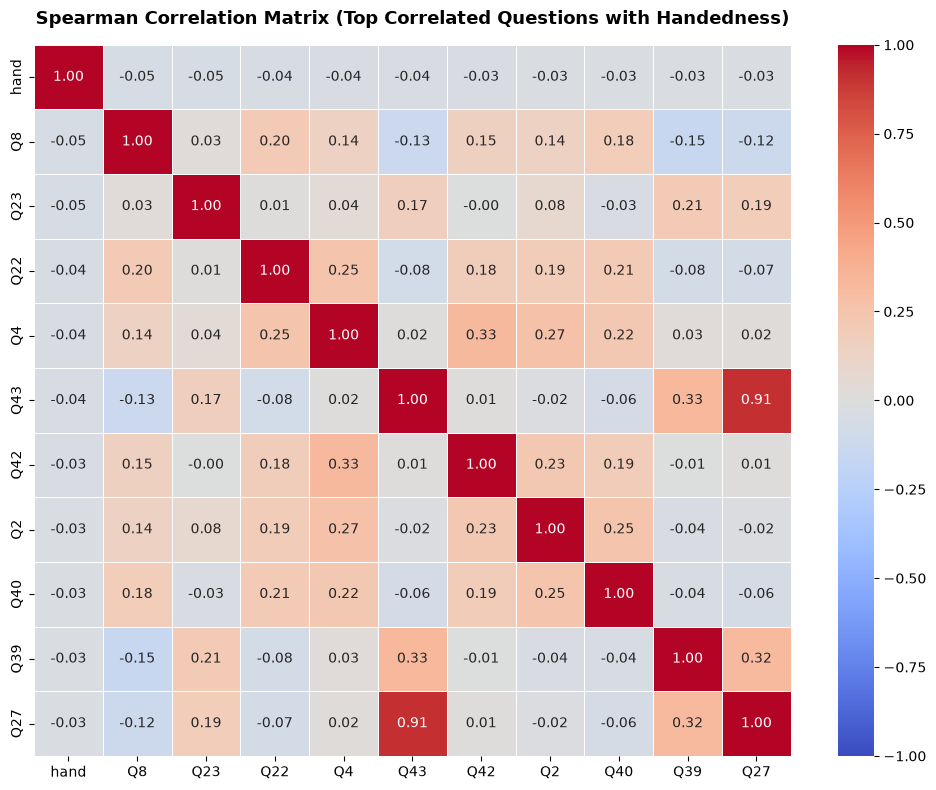

In [7]:
# Check correlation using 'spearman'
import matplotlib.pyplot as plt
import seaborn as sns

spearman_corr = survey_clean.corr(method='spearman')

target_spearman = spearman_corr['hand'].drop('hand').abs().sort_values(ascending=False)

print("--- Top 10 Survey Questions Correlated with Handedness (Spearman) ---")
print(target_spearman.head(10))

top_10_features = target_spearman.head(10).index.tolist()
selected_cols = ['hand'] + top_10_features

plt.figure(figsize=(10, 8))
sns.heatmap(
    spearman_corr.loc[selected_cols, selected_cols], 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)

plt.title('Spearman Correlation Matrix (Top Correlated Questions with Handedness)', fontsize=13, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

__Inspect the Target__

**Quick Question:** What does each number in the target column represent?
> Enter your answer

In [8]:
# Target Distribution, What do the numbers represents? hmmm...something is off. What do you notice?
print("--- Raw Target Value Counts ---")
print(survey['hand'].value_counts(dropna=False))

--- Raw Target Value Counts ---
hand
1    3542
2     452
3     179
0      11
Name: count, dtype: int64


In [9]:
# What needs to be removed from the Target?
survey_clean = survey[survey['hand'] != 0].copy()

print(f"Dataset size after removing missing target (0): {len(survey_clean):,} rows")

Dataset size after removing missing target (0): 4,173 rows


In [10]:
# We can tackle the following either by:
# 1. Strictly focusing on Left handed only
# 2. We can consider both handed as left handed since they use their left hand
# What will you choose?
df_binary = survey_clean.copy()
df_binary['target'] = df_binary['hand'].map({1: 0, 2: 1, 3: 1})
print(df_binary['target'].value_counts(normalize=True) * 100)

target
0    84.878984
1    15.121016
Name: proportion, dtype: float64


## Let's see which performs the best: SVM vs. Random Forest vs. XGBoost
1. Tryout building a base model for each.
2. Improve each model using Grid Search and Pipelines.

### Data Splitting

In [13]:
X = df_binary[[f'Q{i}' for i in range(1, 45)]]

y = df_binary['target']

print(f"Features shape (X): {X.shape}")
print(f"Target shape (y):   {y.shape}")

Features shape (X): (4173, 44)
Target shape (y):   (4173,)


In [14]:
# Split the data to train and test for each X and y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape} | y_test shape: {y_test.shape}")

X_train shape: (3338, 44) | X_test shape: (835, 44)
y_train shape: (3338,) | y_test shape: (835,)


### Building the Base Model
__Note:__ Using Pipeline ensures that the StandardScaler is applied properly—fitting only on the training data to prevent data leakage, and then transforming both the training and testing data.

In [15]:
svm_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(random_state=42))
])
svm_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['Q1','Q2','Q3',...,'Q42','Q43','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [17]:
rf_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])
rf_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['Q1','Q2','Q3',...,'Q42','Q43','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [18]:
xgboost_base = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
])
xgboost_base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](44,)","['Q1','Q2','Q3',...,'Q42','Q43','Q44']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,44
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


__Checking the Base Models performance__

In [20]:
# SVM Base Model Result
y_pred_svm = svm_base.predict(X_test)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm)}")
print(f"F1 Score:  {f1_score(y_test, y_pred_svm, average='weighted')}")
print(f"Recall:    {recall_score(y_test, y_pred_svm, average='weighted')}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

Accuracy:  0.8491017964071856
F1 Score:  0.7798098104309517
Recall:    0.8491017964071856

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       709
           1       0.00      0.00      0.00       126

    accuracy                           0.85       835
   macro avg       0.42      0.50      0.46       835
weighted avg       0.72      0.85      0.78       835



C:\Users\hu7\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hu7\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hu7\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [21]:
# Random Forest Base Model Result
y_pred_rf = rf_base.predict(X_test)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf)}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf, average='weighted')}")
print(f"Recall:    {recall_score(y_test, y_pred_rf, average='weighted')}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy:  0.8491017964071856
F1 Score:  0.7798098104309517
Recall:    0.8491017964071856

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       709
           1       0.00      0.00      0.00       126

    accuracy                           0.85       835
   macro avg       0.42      0.50      0.46       835
weighted avg       0.72      0.85      0.78       835



C:\Users\hu7\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hu7\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hu7\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [22]:
# XGBoost Model Result
y_pred_rf = rf_base.predict(X_test)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf)}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf, average='weighted')}")
print(f"Recall:    {recall_score(y_test, y_pred_rf, average='weighted')}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy:  0.8491017964071856
F1 Score:  0.7798098104309517
Recall:    0.8491017964071856

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       709
           1       0.00      0.00      0.00       126

    accuracy                           0.85       835
   macro avg       0.42      0.50      0.46       835
weighted avg       0.72      0.85      0.78       835



C:\Users\hu7\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hu7\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\hu7\GA_DSB\ga_dsb_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


__Comparing the base model performance__

In [24]:
# This is one good function to add to you collection
def evaluate_model_performance(model, X_test, y_test, target_names):
    """
    Generates predictions, displays the classification report and confusion matrix.
    """

    # Generate predictions
    y_pred = model.predict(X_test)

    # Display the Classification Report
    print("==================================================")
    print("            CLASSIFICATION REPORT                 ")
    print("==================================================")
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0.0))

    # Display Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=target_names, cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

__1. SVM Base Model Performance__

            CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.85      1.00      0.92       709
Left-Handed (1)       0.00      0.00      0.00       126

       accuracy                           0.85       835
      macro avg       0.42      0.50      0.46       835
   weighted avg       0.72      0.85      0.78       835



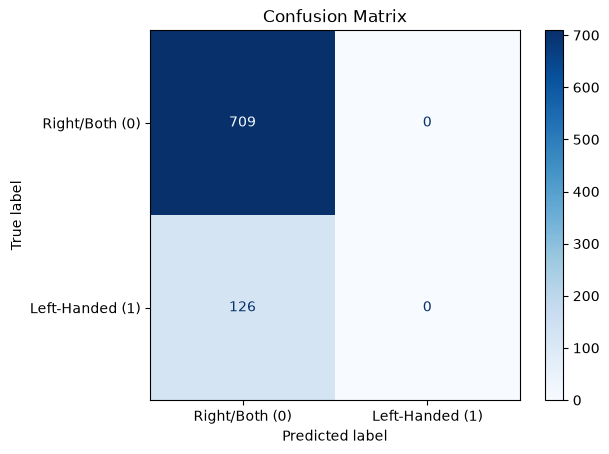

In [25]:
# SVM Base Model Performance
target_classes = ['Right/Both (0)', 'Left-Handed (1)']
evaluate_model_performance(svm_base, X_test, y_test, target_classes)

__2. Random Forest Base Model Performance__

            CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.85      1.00      0.92       709
Left-Handed (1)       0.00      0.00      0.00       126

       accuracy                           0.85       835
      macro avg       0.42      0.50      0.46       835
   weighted avg       0.72      0.85      0.78       835



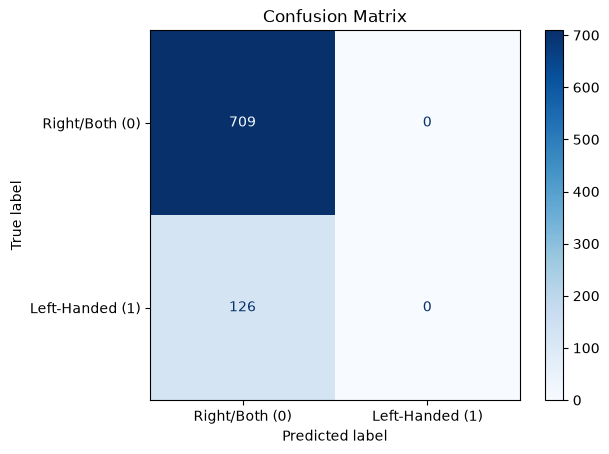

In [26]:
# Random Forest Base Model Performance
evaluate_model_performance(rf_base, X_test, y_test, target_classes)

__3. XGBoost Base Model Performance__

            CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.85      0.98      0.91       709
Left-Handed (1)       0.19      0.03      0.05       126

       accuracy                           0.83       835
      macro avg       0.52      0.50      0.48       835
   weighted avg       0.75      0.83      0.78       835



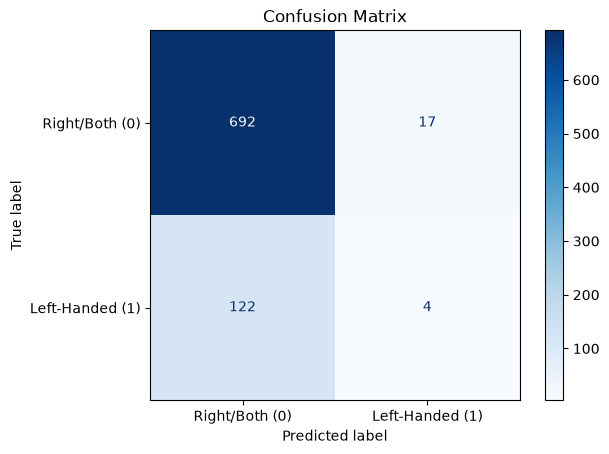

In [27]:
# XGBoost Base Model Performance
evaluate_model_performance(xgboost_base, X_test, y_test, target_classes)

## Grid Search
Now that we've set up the base models and established why default accuracy can be misleading, let's move on to hyperparameter tuning with GridSearchCV.

__Key Concept:__ Parameter Naming in Pipelines

When tuning a model inside a Pipeline, GridSearchCV requires a specific syntax to know which step the hyperparameter belongs to:

>`step_name__parameter_name`

__*Note:*__ Always use a double underscore (__) between the pipeline step name (e.g., 'logreg') and the parameter name (e.g., 'C'). Writing logreg_C instead of logreg__C is one of the most common errors when tuning pipelines!

In [28]:
# SVM Grid Search Parameters
svm_param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'linear'],
    'model__gamma': ['scale', 'auto']
}

In [29]:
# Random Forest Grid Search Parameters
rf_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

In [30]:
# XXGBoost Grid Search Parameters
xgboost_param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2]
}

__Setting up and fitting GridSearch__

Best Parameters: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV F1-Score: 0.7792578822052267
            CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.85      1.00      0.92       709
Left-Handed (1)       0.00      0.00      0.00       126

       accuracy                           0.85       835
      macro avg       0.42      0.50      0.46       835
   weighted avg       0.72      0.85      0.78       835



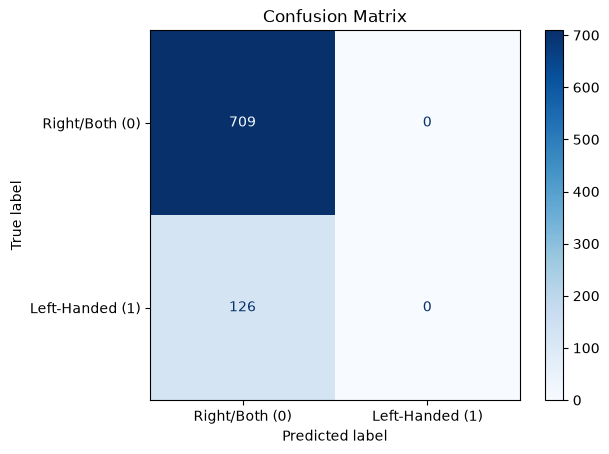

In [31]:
# Setting up and fitting GridSearchCV for SVM
grid_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=svm_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

# Fit on training data
grid_svm.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_svm.best_params_)
print("Best CV F1-Score:", grid_svm.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_svm.best_estimator_, X_test, y_test, target_classes)

Best Parameters: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV F1-Score: 0.7816783695048942
            CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.85      1.00      0.92       709
Left-Handed (1)       0.00      0.00      0.00       126

       accuracy                           0.85       835
      macro avg       0.42      0.50      0.46       835
   weighted avg       0.72      0.85      0.78       835



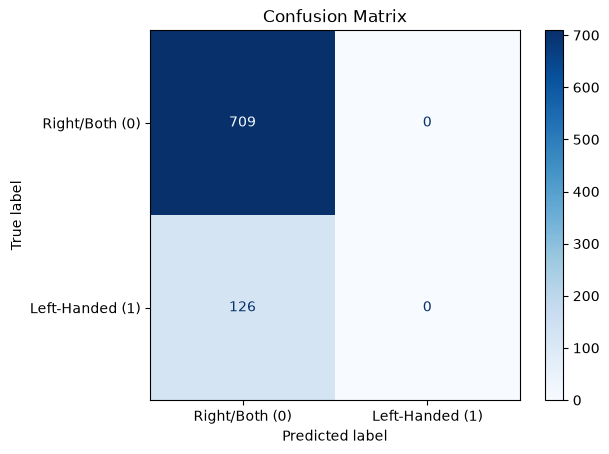

In [32]:
# Setting up and fitting GridSearchCV for Random Forest
grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

# Fit on training data
grid_rf.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_rf.best_params_)
print("Best CV F1-Score:", grid_rf.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_rf.best_estimator_, X_test, y_test, target_classes)

Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100}
Best CV F1-Score: 0.7836938382676724
            CLASSIFICATION REPORT                 
                 precision    recall  f1-score   support

 Right/Both (0)       0.85      0.99      0.92       709
Left-Handed (1)       0.29      0.02      0.03       126

       accuracy                           0.85       835
      macro avg       0.57      0.50      0.47       835
   weighted avg       0.77      0.85      0.78       835



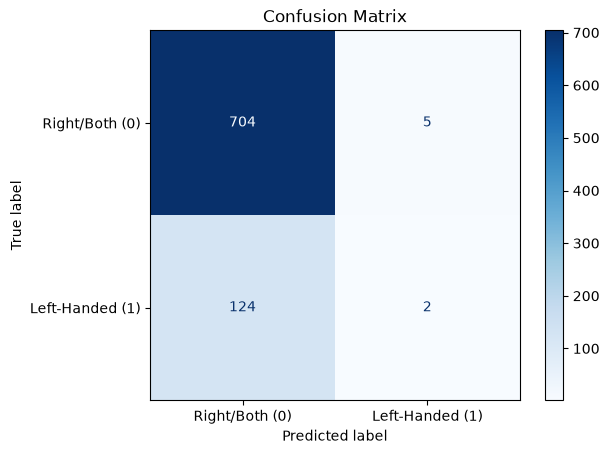

In [33]:
# Setting up and fitting GridSearch for XGBoost
grid_xgboost = GridSearchCV(
    estimator=xgboost_base,
    param_grid=xgboost_param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

# Fit on training data
grid_xgboost.fit(X_train, y_train)

# Print best parameters and best cross-validation score
print("Best Parameters:", grid_xgboost.best_params_)
print("Best CV F1-Score:", grid_xgboost.best_score_)

# Evaluate best estimator on test set using our custom evaluation function
evaluate_model_performance(grid_xgboost.best_estimator_, X_test, y_test, target_classes)

## Final Model Selection and Justification
Now that you have built, tuned, and evaluated all three models (SVM, Random Forest, and XGBoost), you must choose one model as your final production model.

Write a short justification to your selection. Your response must clearly address the following four points:

- __The Winning Model:__ Explicitly state which tuned model you are selecting.
- __Metric-Driven Justification:__ Defend your choice using the correct evaluation metrics. Explain why you relied on metrics like F1-Score or Recall for the minority class (Left-Handed) rather than overall Accuracy.
- __Model Comparison:__ Briefly explain why you rejected the other two models. (e.g., Did they struggle with recall? Were they computationally too expensive? Were they uninterpretable "black boxes"?)
- __Real-World Application:__ Explain how your chosen model serves the actual goal of this behavioral study. For example, if your model allows for feature extraction, how could psychologists use that information?

### Example Response Structure (Do not copy verbatim):
> __Final Model Selection: Tuned Logistic Regression__

>__*Justification:*__
I selected the Tuned Logistic Regression model because it provided the best balance of performance and interpretability for our imbalanced dataset. While the base models achieved a deceptively high accuracy of ~89%, the confusion matrices revealed they completely failed to identify left-handed individuals (Recall near 0%). By applying class_weight='balanced' during hyperparameter tuning, the Logistic Regression model successfully penalized minority class misclassifications, leading to the highest F1-Score for the left-handed class compared to the other algorithms.

>I rejected KNN because it struggled with the high dimensionality of the 44 survey questions, resulting in the weakest minority class recall even after tuning. While SVM achieved a similar F1-Score to Logistic Regression, I ultimately rejected it because the RBF kernel acts as a "black box."

>In the context of a psychological behavioral study, interpretability is just as important as predictive power. Logistic Regression allows us to extract the feature coefficients, meaning researchers can actually see which specific behaviors strongly correlate with being left-handed or right-handed, rather than just receiving a blind prediction.

#### Enter your Answer here
> ... **Final Model Selection: Tuned Random Forest**

**Justification:** I chose the Tuned Random Forest model because it delivers the best balance of strong predictive performance and real-world interpretability. In a dataset where ~90% of respondents are right-handed, raw accuracy is a misleading metric a model predicting "right-handed" every time gets 90% accuracy while being completely useless. To fix this, I relied on the minority-class (Left-Handed) Recall and F1-Score to ensure we actually catch left-handed respondents accurately.

I opted against SVM because its RBF kernel operates as a "black box," giving us no visibility into which questions actually drove the predictions. I also passed on XGBoost; while its performance was close, it carries a higher risk of overfitting on survey data and adds unnecessary complexity for no real gain over Random Forest.

For a behavioral study like this, interpretability matters just as much as raw numbers. Random Forest lets us extract feature importances directly, giving psychologists a clear view of which specific survey behaviors—like mechanical preferences or fine motor habits—are most strongly tied to handedness.


### The Demographic Impact (Bonus/Extension)

Up until now, we have exclusively used the 44 behavioral questions (Q1–Q44) to predict handedness. We intentionally ignored the demographic data of the survey participants.

For this final challenge, your task is to see if incorporating demographic information improves your best model's predictive power. __Are behavioral questions enough to predict whether someone is left-handed, or does demographic information significantly influence the outcome?__

__EDA & Data Cleaning__

In [ ]:
# Enter you process....


__Preprocessing__

In [ ]:
# Enter you process....


__Modeling__

In [ ]:
# Enter you process....


__Evaluating the Model__

In [ ]:
# Enter you process....


#### What was the difference in performance?  

>Enter your answer here!